# Exploratory Data Analysis & Data Cleaning

This notebook covers the initial data loading, descriptive analysis, quality filtering via engagement threshold, and string processing for features.

## 1. Data Loading & Descriptive Analysis

### 1.1 Dataset Loading and Structural Overview

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
df_movies = pd.read_csv('../datasets/movies.csv')
df_ratings = pd.read_csv('../datasets/ratings.csv')

print(f"Initial Movies Shape: {df_movies.shape}")
print(f"Initial Ratings Shape: {df_ratings.shape}")

Initial Movies Shape: (10329, 3)
Initial Ratings Shape: (105339, 4)


In [2]:
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [4]:
df_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 10329 entries, 0 to 10328
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  10329 non-null  int64
 1   title    10329 non-null  str  
 2   genres   10329 non-null  str  
dtypes: int64(1), str(2)
memory usage: 242.2 KB


In [5]:
df_ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 105339 entries, 0 to 105338
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     105339 non-null  int64  
 1   movieId    105339 non-null  int64  
 2   rating     105339 non-null  float64
 3   timestamp  105339 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.2 MB


In [6]:
sorted(df_ratings['rating'].unique())

[np.float64(0.5),
 np.float64(1.0),
 np.float64(1.5),
 np.float64(2.0),
 np.float64(2.5),
 np.float64(3.0),
 np.float64(3.5),
 np.float64(4.0),
 np.float64(4.5),
 np.float64(5.0)]

### 1.2 Data Integrity and Duplicates Check

#### 1.2.1 Resolving Duplicate Titles in Movies Dataset

In [7]:
df_movies.duplicated(subset=['movieId']).sum()

np.int64(0)

In [8]:
df_movies.duplicated(subset=['title']).sum()

np.int64(2)

In [9]:
df_movies[df_movies.duplicated(subset=['title'], keep=False)]

,movieId,title,genres
1403,1788,Men with Guns (1997),Action|Drama
6270,26982,Men with Guns (1997),Drama
6662,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller
7963,64997,War of the Worlds (2005),Action|Sci-Fi


In [10]:
df_movies = df_movies[~df_movies['movieId'].isin([26982, 64997])]
df_movies[df_movies['title'].isin(['Men with Guns (1997)','War of the Worlds (2005)'])]

,movieId,title,genres
1403,1788,Men with Guns (1997),Action|Drama
6662,34048,War of the Worlds (2005),Action|Adventure|Sci-Fi|Thriller


In [11]:
df_movies.duplicated(subset=['title']).sum()

np.int64(0)

In [12]:
df_movies.describe()

,movieId
count,10327.000000
mean,31921.558923
std,37736.960408
min,1.000000
25%,3239.000000
50%,7087.000000
75%,59875.000000
max,149532.000000


#### 1.2.2 Mapping Referential Integrity in Ratings Dataset

In [13]:
# Visualize the impact on the ratings dataset
df_ratings[df_ratings['movieId'].isin([1788, 26982, 34048, 64997])]['movieId'].value_counts()

movieId
34048    33
1788      3
64997     3
26982     2
Name: count, dtype: int64

In [14]:
# Overwrite movie IDs
df_ratings['movieId'] = df_ratings['movieId'].replace({
    26982: 1788,
    64997: 34048
})

df_ratings[df_ratings['movieId'].isin([1788, 26982, 34048, 64997])]['movieId'].value_counts()

movieId
34048    36
1788      5
Name: count, dtype: int64

In [15]:
df_ratings.duplicated(subset=['userId', 'movieId']).sum()

np.int64(4)

In [16]:
df_ratings[df_ratings.duplicated(subset=['userId', 'movieId'], keep=False)]

,userId,movieId,rating,timestamp
65300,458,1788,4.0,953240952
66400,458,1788,4.0,1321471892
68037,461,34048,3.0,1179853684
68133,461,34048,3.0,1264802172
84877,575,34048,2.5,1134580874
85181,575,34048,2.0,1231171245
100401,668,1788,3.0,1047330516
102949,668,1788,3.0,1223578115


In [17]:
df_ratings = df_ratings.drop_duplicates(subset=['userId', 'movieId'], keep='first')
df_ratings.duplicated(subset=['userId', 'movieId']).sum()

np.int64(0)

In [18]:
df_ratings.describe()

,userId,movieId,rating,timestamp
count,105335.000000,105335.000000,105335.000000,1.053350e+05
mean,364.917872,13379.780396,3.516870,1.130419e+09
std,197.486955,26169.514389,1.044878,1.802675e+08
min,1.000000,1.000000,0.500000,8.285650e+08
25%,192.000000,1073.000000,3.000000,9.711007e+08
50%,383.000000,2496.000000,3.500000,1.115042e+09
75%,557.000000,5991.000000,4.000000,1.275496e+09
max,668.000000,149532.000000,5.000000,1.452405e+09


## 2. Engagement Distribution & Threshold Filtering

Analyzing the volume of interactions per movie and per user to define a minimum quality threshold, reducing noise and the Cold Start problem.

### 2.1 Movie Interaction Analysis

In [19]:
rating_counts = df_ratings.groupby('movieId')['rating'].count().reset_index()
rating_counts['rating'].describe()

count    10323.000000
mean        10.203914
std         22.834399
min          1.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        325.000000
Name: rating, dtype: float64

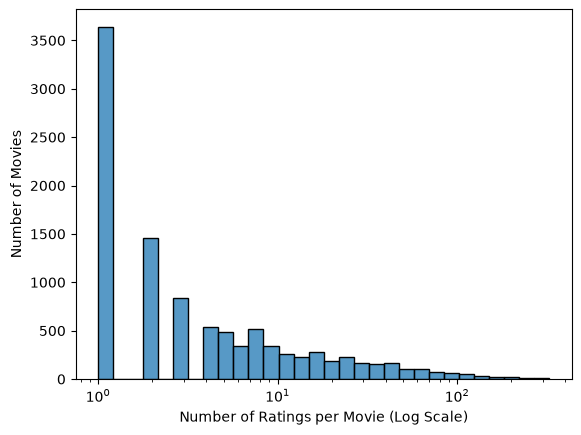

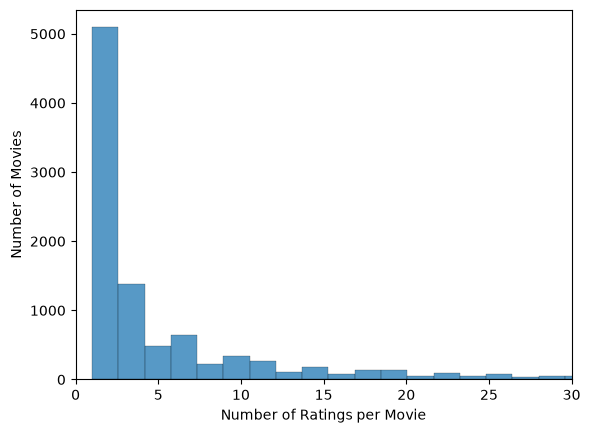

In [20]:
# Plot the histogram using a logarithmic scale
sns.histplot(data=rating_counts, x='rating', log_scale=True, bins=30, kde=False)
plt.xlabel('Number of Ratings per Movie (Log Scale)')
plt.ylabel('Number of Movies')
plt.show()

# Plot the histogram with the x-axis limited to 30 ratings.
sns.histplot(data=rating_counts, x='rating')
plt.xlim(0, 30)
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Number of Movies')
plt.show()

### 2.2 User Engagement Analysis

In [21]:
ratings_per_user = df_ratings.groupby('userId')['rating'].count()
ratings_per_user.describe()

count     668.000000
mean      157.687126
std       319.661050
min        20.000000
25%        35.000000
50%        70.500000
75%       153.000000
max      5677.000000
Name: rating, dtype: float64

### 2.3 Data Filtering (Applying the Threshold)

Decision: Keep only movies with 3 or more ratings to eliminate low-interaction noise. All users are preserved since the minimum activity is 20 ratings.

In [22]:
# Identify movies with enough ratings to be included in the analysis
valid_movie_ids = rating_counts.query('rating >= 3')['movieId']
valid_movie_ids

0             1
1             2
2             3
3             4
4             5
          ...  
10259    135887
10261    136020
10270    138036
10281    139644
10321    148626
Name: movieId, Length: 5231, dtype: int64

In [23]:
# Keep only ratings for movies that meet the minimum rating count
filtered_ratings = df_ratings[df_ratings['movieId'].isin(valid_movie_ids)]

total_ratings = df_ratings.shape[0]
remaining_ratings = filtered_ratings.shape[0]
removed_ratings = total_ratings - remaining_ratings

print(
    f'Ratings before filtering : {total_ratings}\n'
    f'Ratings removed          : {removed_ratings}\n'
    f'Ratings remaining        : {remaining_ratings}'
)

Ratings before filtering : 105335
Ratings removed          : 6546
Ratings remaining        : 98789


In [24]:
# Keep only movies that meet the minimum rating count
filtered_movies = df_movies[df_movies['movieId'].isin(valid_movie_ids)]

total_movies = df_movies.shape[0]
remaining_movies = filtered_movies.shape[0]
removed_movies = total_movies - remaining_movies

print(
    f'Movies before filtering : {total_movies}\n'
    f'Movies removed          : {removed_movies} (< 3 ratings)\n'
    f'Movies remaining        : {remaining_movies}'
)

Movies before filtering : 10327
Movies removed          : 5096 (< 3 ratings)
Movies remaining        : 5231


## 3. Feature Engineering & Text Processing

Now that the datasets have been filtered and optimized, we can process individual columns to extract meaningful features for the recommendation engine.

### 3.1 Ratings Dataset

In [25]:
filtered_ratings = filtered_ratings.drop(columns=['timestamp'])
filtered_ratings.head()

,userId,movieId,rating
0,1,16,4.0
1,1,24,1.5
2,1,32,4.0
3,1,47,4.0
4,1,50,4.0


### 3.2 Movies Dataset

#### Title

In [26]:
filtered_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


##### 1. Extract Release Year

In [27]:
filtered_movies['year'] = (
    filtered_movies['title']
    .str.extract(r'\((\d{4})\)')[0]
    .fillna(0).astype(int)
)

filtered_movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995


In [28]:
filtered_movies[filtered_movies['year'].isna()]

,movieId,title,genres,year


In [29]:
filtered_movies[filtered_movies['year'] == 0]

,movieId,title,genres,year
9885,108583,Fawlty Towers (1975-1979),Comedy,0


##### 2. Remove Outliers

In [30]:
outlier_movie_id = 108583

In [31]:
filtered_movies = filtered_movies[
    filtered_movies['movieId'] != outlier_movie_id
]

filtered_movies['year'].isna().sum()

np.int64(0)

In [32]:
filtered_ratings[filtered_ratings['movieId'] == outlier_movie_id]['movieId'].count()

np.int64(5)

In [33]:
filtered_ratings = filtered_ratings[
    filtered_ratings['movieId'] != outlier_movie_id
]

filtered_ratings[
    filtered_ratings['movieId'] == outlier_movie_id
]['movieId'].count()

np.int64(0)

##### 3. Clean Movie Titles

In [34]:
filtered_movies['title'] = (
    filtered_movies['title']
    .str.replace(r'\s*\(\d{4}\)', '', regex=True)
    .str.strip()
)

filtered_movies.head()

,movieId,title,genres,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


In [35]:
filtered_movies.info()

<class 'pandas.DataFrame'>
Index: 5230 entries, 0 to 10327
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  5230 non-null   int64
 1   title    5230 non-null   str  
 2   genres   5230 non-null   str  
 3   year     5230 non-null   int64
dtypes: int64(2), str(2)
memory usage: 204.3 KB


#### Genres

##### Genre Availability Check

In [36]:
df_movies[df_movies['genres'] == '(no genres listed)']

,movieId,title,genres
10172,126929,Li'l Quinquin ( ),(no genres listed)
10260,135460,Pablo (2012),(no genres listed)
10280,138863,The Big Broadcast of 1936 (1935),(no genres listed)
10301,141305,Round Trip to Heaven (1992),(no genres listed)
10303,141472,The 50 Year Argument (2014),(no genres listed)
10317,143709,The Take (2009),(no genres listed)
10328,149532,Marco Polo: One Hundred Eyes (2015),(no genres listed)


In [37]:
filtered_movies[filtered_movies['genres'] == '(no genres listed)']

,movieId,title,genres,year


##### One-Hot Encoding

In [38]:
filtered_movies = filtered_movies.reset_index(drop=True)

# Create binary genre features
genre_dummies = filtered_movies['genres'].str.get_dummies('|', dtype=int)
genre_dummies.columns = genre_dummies.columns.str.lower()
genre_dummies.sum()

action         1159
adventure       777
animation       250
children        357
comedy         1924
crime           796
documentary     109
drama          2486
fantasy         429
film-noir        58
horror          491
imax            126
musical         194
mystery         376
romance         958
sci-fi          589
thriller       1306
war             244
western          95
dtype: int64

In [39]:
ordered_columns = ['movieId', 'title', 'year', 'genres']
df_reordered = filtered_movies[ordered_columns]
filtered_movies = pd.concat([df_reordered, genre_dummies], axis=1).drop(columns=['genres'])
filtered_movies.head()

,movieId,title,year,action,adventure,animation,children,comedy,crime,documentary,...,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,war,western
0,1,Toy Story,1995,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji,1995,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men,1995,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale,1995,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II,1995,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
filtered_movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 5230 entries, 0 to 5229
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   movieId      5230 non-null   int64
 1   title        5230 non-null   str  
 2   year         5230 non-null   int64
 3   action       5230 non-null   int64
 4   adventure    5230 non-null   int64
 5   animation    5230 non-null   int64
 6   children     5230 non-null   int64
 7   comedy       5230 non-null   int64
 8   crime        5230 non-null   int64
 9   documentary  5230 non-null   int64
 10  drama        5230 non-null   int64
 11  fantasy      5230 non-null   int64
 12  film-noir    5230 non-null   int64
 13  horror       5230 non-null   int64
 14  imax         5230 non-null   int64
 15  musical      5230 non-null   int64
 16  mystery      5230 non-null   int64
 17  romance      5230 non-null   int64
 18  sci-fi       5230 non-null   int64
 19  thriller     5230 non-null   int64
 20  war          5230 n

## 4. Exporting Processed Data

In [41]:
output_dir = '../datasets/processed'
os.makedirs(output_dir, exist_ok=True)

filtered_movies.to_csv(f'{output_dir}/movies_cleaned.csv', index=False)
filtered_ratings.to_csv(f'{output_dir}/ratings_cleaned.csv', index=False)